In [ ]:
import numpy as np
from gymnasium.wrappers import TimeLimit
from my_cartpole_env import CartPoleEnv
from plotting import plot_returns
from collections import deque
from hyperparameters import *
from common import *
THETA_LIMIT = np.deg2rad(25)

In [77]:
def evaluate_agent(env, type, policy=None, Q=None, NUM_EPISODES_EVAL=NUM_EPISODES_EVAL):
    if type == "Q":
        assert Q is not None
    elif type == "DP":
        assert policy is not None
    elif type == "MPC":
        # NUM_EPISODES_EVAL=10
        assert policy is not None
    else:
        raise ValueError(f"Invalid type: {type}")

    state, _ = env.reset()
    episode_reward = 0
    term_flags = []

    returns = deque(maxlen=NUM_EPISODES_EVAL)

    for i in range(NUM_EPISODES_EVAL):
        state, _ = env.reset()
        # Reset MPC warm start buffer for new episode
        if type == "MPC":
            policy.reset()
        episode_reward = 0
        terminated_any = False

        while True:
            indices = state_to_indices(state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
            
            if type == "Q":
                action = np.argmax(Q[indices])
            elif type == "DP":
                action = policy[indices]
            elif type == "MPC":
                action = policy.control(state)
            state, _, terminated, truncated, _ = env.step(action)
            reward = reward_function(state, terminated) * (-1 if type == "Q" else 1)
            episode_reward += reward

            if terminated:
                    terminated_any = True

            if terminated or truncated:
                term_flags.append(terminated_any)
                returns.append(episode_reward)
                print(f"Episode {i} Mean Return: {np.mean(returns)}", end="\r")
                break

    term_flags = np.array(term_flags, dtype=float)
    print("Terminattion Rate: {:.2f}%".format(np.mean(term_flags) * 100))
    env.close()
    return returns, term_flags


In [ ]:
sr=[]
st=[]
Q= np.zeros((N_BINS, N_BINS, N_BINS, N_BINS, 2))
def run_q_learning(env,train_timesteps_M):
    
    returns = deque(maxlen=1000)
    returns.append(0)
    saved_returns = []
    saved_timesteps = []
    episode = 0
    state, _ = env.reset()
    episode_reward = 0
    ALPHA=0.1

    # Learning rate and exploration rate schedules flags
    alpha_schedule = False
    epsilon_schedule = False

    for timestep in range(int(train_timesteps_M * 1e6)):
        
        if epsilon_schedule:
            ### FILL IN HERE ###
            current_epsilon = EPSILON
            # current_epsilon = max(0.01, EPSILON * (1 - timestep / (train_timesteps_M * 1e6)))
            # raise NotImplementedError("Epsilon schedule not implemented")
        else:
            current_epsilon = EPSILON

        if alpha_schedule:
            ### FILL IN HERE ###
            current_alpha = ALPHA
            # raise NotImplementedError("Alpha schedule not implemented")
        else:
            current_alpha = ALPHA

        indices = state_to_indices(state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        
        ### FILL IN HERE ###
        if np.random.rand() < current_epsilon:
            action = np.random.randint(2)
        else:
            action = np.argmax(Q[indices])
        # raise NotImplementedError("Action selection not implemented")

        next_state, _, terminated, truncated, _ = env.step(int(action))
        next_indices = state_to_indices(next_state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        reward = reward_function(next_state, terminated) * -1
        episode_reward += reward

        # Q-value update
        best_next_q = np.max(Q[next_indices])
        ### FILL IN HERE ###
        Q[indices + (action,)] += current_alpha * (reward + GAMMA * best_next_q - Q[indices + (action,)])
        # raise NotImplementedError("Q-value update not implemented")

        state = next_state
        if terminated or truncated:
            returns.append(episode_reward)
            episode += 1
            state, _ = env.reset()
            episode_reward = 0
      
        if timestep % 20000 == 0 and timestep > 0:
            print(f"Timestep {timestep/1e6:.2f}M | Return: {np.mean(returns):.4f} | Eps: {current_epsilon:.5f} | Alpha: {current_alpha:.5f}")
            sr.append(np.mean(returns))
            st.append(timestep/1e6)
            # plot_returns(saved_returns, saved_timesteps)

    return Q

In [ ]:

if __name__ == "__main__":

    # train agent
    train_env = CartPoleEnv(x_threshold=X_LIMIT, theta_threshold_radians=THETA_LIMIT)
    train_env = TimeLimit(train_env, max_episode_steps=MAX_EPISODE_STEPS)
    # train_env = TimeLimit(train_env, max_episode_steps=10)
    Q = run_q_learning(train_env, train_timesteps_M=TRAIN_TIMESTEPS_M*10)

    # evaluate agent
    returns = evaluate_agent(train_env, type="Q", Q=Q)
    print_statistics(returns)
    train_env.close()

    # # play agent
    # play_env = CartPoleEnv(render_mode="human", x_threshold=X_LIMIT, theta_threshold_radians=THETA_LIMIT)
    # play_env = TimeLimit(play_env, max_episode_steps=MAX_EPISODE_STEPS)
    # play_agent(play_env, type="Q", Q=Q)
    # play_env.close()



3a)

In [ ]:
import matplotlib.pyplot as plt

def plot_returns(returns, timesteps):
    plt.plot(timesteps, returns)
    plt.xlabel('Timesteps (M)')
    plt.ylabel('Return')
    plt.title('Returns')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('returns.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)

plot_returns(sr, st)

In [ ]:
ALPHA=0.9

In [ ]:
Qa = np.zeros((N_BINS, N_BINS, N_BINS, N_BINS, 2))
def run_q_learning2(env,train_timesteps_M, alpha_schedule=False, epsilon_schedule=False):

    sri=[]
    sti=[]
    
    returns = deque(maxlen=1000)
    returns.append(0)
    saved_returns = []
    saved_timesteps = []
    episode = 0
    state, _ = env.reset()
    episode_reward = 0

    ALPHA=0.9
    alpha_min = 0.02
    decay_rate = 6.0
    epsilon_min = 0.01

    current_alpha=ALPHA
    current_epsilon = EPSILON
    T = train_timesteps_M * 1e6

    for timestep in range(int(train_timesteps_M * 1e6)):
        
        if epsilon_schedule:
            ### FILL IN HERE ###
            current_epsilon = epsilon_min + (EPSILON - epsilon_min) * np.exp(-decay_rate * timestep / T)
            # current_epsilon = max(0.01, EPSILON * (1 - timestep / (train_timesteps_M * 1e6)))
            # raise NotImplementedError("Epsilon schedule not implemented")
        else:
            current_epsilon = current_epsilon

        if alpha_schedule:
            ### FILL IN HERE ###
            current_alpha = alpha_min + (ALPHA - alpha_min) * np.exp(-decay_rate * timestep / T)

            # raise NotImplementedError("Alpha schedule not implemented")
        else:
            current_alpha = current_alpha

        indices = state_to_indices(state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        
        ### FILL IN HERE ###
        if np.random.rand() < current_epsilon:
            action = np.random.randint(2)
        else:
            action = np.argmax(Qa[indices])
        # raise NotImplementedError("Action selection not implemented")

        next_state, _, terminated, truncated, _ = env.step(int(action))
        next_indices = state_to_indices(next_state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        reward = reward_function(next_state, terminated) * -1
        episode_reward += reward

        # Q-value update
        best_next_q = np.max(Qa[next_indices])
        ### FILL IN HERE ###
        Qa[indices + (action,)] += current_alpha * (reward + GAMMA * best_next_q - Qa[indices + (action,)])
        # raise NotImplementedError("Q-value update not implemented")

        state = next_state
        if terminated or truncated:
            returns.append(episode_reward)
            episode += 1
            state, _ = env.reset()
            episode_reward = 0
      
        if timestep % 20000 == 0 and timestep > 0:
            print(f"Timestep {timestep/1e6:.2f}M | Return: {np.mean(returns):.4f} | Eps: {current_epsilon:.5f} | Alpha: {current_alpha:.5f}")
            sri.append(np.mean(returns))
            sti.append(timestep/1e6)
            # plot_returns(saved_returns, saved_timesteps)

    return Qa,sri,sti

In [ ]:
train_env2 = CartPoleEnv(x_threshold=X_LIMIT, theta_threshold_radians=THETA_LIMIT)
train_env2 = TimeLimit(train_env2, max_episode_steps=MAX_EPISODE_STEPS)
# train_env = TimeLimit(train_env, max_episode_steps=10)
Qa,sra,sta = run_q_learning2(train_env2, train_timesteps_M=TRAIN_TIMESTEPS_M*10, alpha_schedule=True, epsilon_schedule=False)

In [ ]:
import matplotlib.pyplot as plt

def plot_returns2(returns, returnsa, timesteps):
    plt.plot(timesteps, returns, label='returns')
    plt.plot(timesteps, returnsa, label='returnsa')
    plt.legend()
    plt.xlabel('Timesteps (M)')
    plt.ylabel('Return')
    plt.title('Returns')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('returnsvsretunsalpha.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)

plot_returns2(sr, sra, st)

In [ ]:
Qae = np.zeros((N_BINS, N_BINS, N_BINS, N_BINS, 2))
def run_q_learning2(env,train_timesteps_M, alpha_schedule=False, epsilon_schedule=False):

    sri=[]
    sti=[]
    
    returns = deque(maxlen=1000)
    returns.append(0)
    saved_returns = []
    saved_timesteps = []
    episode = 0
    state, _ = env.reset()
    episode_reward = 0

    ALPHA=1
    EPSILON=0.01
    alpha_min = 0.02
    decay_rate = 10
    epsilon_min = 0.001

    current_alpha=ALPHA
    T = train_timesteps_M * 1e6

    for timestep in range(int(train_timesteps_M * 1e6)):
        
        if epsilon_schedule:
            ### FILL IN HERE ###
            current_epsilon = epsilon_min + (EPSILON - epsilon_min) * np.exp(-decay_rate * timestep / T)
            # current_epsilon = max(0.01, EPSILON * (1 - timestep / (train_timesteps_M * 1e6)))
            # raise NotImplementedError("Epsilon schedule not implemented")
        else:
            current_epsilon = current_epsilon

        if alpha_schedule:
            ### FILL IN HERE ###
            current_alpha = alpha_min + (ALPHA - alpha_min) * np.exp(-decay_rate * timestep / T)

            # raise NotImplementedError("Alpha schedule not implemented")
        else:
            current_alpha = current_alpha

        indices = state_to_indices(state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        
        ### FILL IN HERE ###
        if np.random.rand() < current_epsilon:
            action = np.random.randint(2)
        else:
            action = np.argmax(Qae[indices])
        # raise NotImplementedError("Action selection not implemented")

        next_state, _, terminated, truncated, _ = env.step(int(action))
        next_indices = state_to_indices(next_state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        reward = reward_function(next_state, terminated) * -1
        episode_reward += reward

        # Q-value update
        best_next_q = np.max(Qae[next_indices])
        ### FILL IN HERE ###
        Qae[indices + (action,)] += current_alpha * (reward + GAMMA * best_next_q - Qae[indices + (action,)])
        # raise NotImplementedError("Q-value update not implemented")

        state = next_state
        if terminated or truncated:
            returns.append(episode_reward)
            episode += 1
            state, _ = env.reset()
            episode_reward = 0
      
        if timestep % 20000 == 0 and timestep > 0:
            print(f"Timestep {timestep/1e6:.2f}M | Return: {np.mean(returns):.4f} | Eps: {current_epsilon:.5f} | Alpha: {current_alpha:.5f}")
            sri.append(np.mean(returns))
            sti.append(timestep/1e6)
            # plot_returns(saved_returns, saved_timesteps)

    return Qae,sri,sti

In [ ]:
train_env3 = CartPoleEnv(x_threshold=X_LIMIT, theta_threshold_radians=THETA_LIMIT)
train_env3 = TimeLimit(train_env3, max_episode_steps=MAX_EPISODE_STEPS)
# train_env = TimeLimit(train_env, max_episode_steps=10)
Qae,srae,stae = run_q_learning2(train_env3, train_timesteps_M=TRAIN_TIMESTEPS_M*10, alpha_schedule=True, epsilon_schedule=True)

In [ ]:
import matplotlib.pyplot as plt

def plot_returns2(returns, returnsa, timesteps):
    plt.plot(timesteps, returns, label='returns - alpha schedule')
    plt.plot(timesteps, returnsa, label='returns - alpha + epsilon schedule')
    plt.legend()
    plt.xlabel('Timesteps (M)')
    plt.ylabel('Return')
    plt.title('Returns')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('returnsalphavsretunsepsilon.pdf.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)

plot_returns2(sra, srae, st)

In [ ]:
N_BINS = 30
Qae40 = np.zeros((N_BINS, N_BINS, N_BINS, N_BINS, 2))
def run_q_learning2(env,train_timesteps_M, alpha_schedule=False, epsilon_schedule=False):

    sri=[]
    sti=[]
    
    returns = deque(maxlen=1000)
    returns.append(0)
    saved_returns = []
    saved_timesteps = []
    episode = 0
    state, _ = env.reset()
    episode_reward = 0

    ALPHA=1
    EPSILON=0.01
    alpha_min = 0.02
    decay_rate = 10
    epsilon_min = 0.001

    current_alpha=ALPHA
    T = train_timesteps_M * 1e6

    for timestep in range(int(train_timesteps_M * 1e6)):
        
        if epsilon_schedule:
            ### FILL IN HERE ###
            current_epsilon = epsilon_min + (EPSILON - epsilon_min) * np.exp(-decay_rate * timestep / T)
            # current_epsilon = max(0.01, EPSILON * (1 - timestep / (train_timesteps_M * 1e6)))
            # raise NotImplementedError("Epsilon schedule not implemented")
        else:
            current_epsilon = current_epsilon

        if alpha_schedule:
            ### FILL IN HERE ###
            current_alpha = alpha_min + (ALPHA - alpha_min) * np.exp(-decay_rate * timestep / T)

            # raise NotImplementedError("Alpha schedule not implemented")
        else:
            current_alpha = current_alpha

        indices = state_to_indices(state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        
        ### FILL IN HERE ###
        if np.random.rand() < current_epsilon:
            action = np.random.randint(2)
        else:
            action = np.argmax(Qae40[indices])
        # raise NotImplementedError("Action selection not implemented")

        next_state, _, terminated, truncated, _ = env.step(int(action))
        next_indices = state_to_indices(next_state, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        reward = reward_function(next_state, terminated) * -1
        episode_reward += reward

        # Q-value update
        best_next_q = np.max(Qae40[next_indices])
        ### FILL IN HERE ###
        Qae40[indices + (action,)] += current_alpha * (reward + GAMMA * best_next_q - Qae40[indices + (action,)])
        # raise NotImplementedError("Q-value update not implemented")

        state = next_state
        if terminated or truncated:
            returns.append(episode_reward)
            episode += 1
            state, _ = env.reset()
            episode_reward = 0
      
        if timestep % 20000 == 0 and timestep > 0:
            print(f"Timestep {timestep/1e6:.2f}M | Return: {np.mean(returns):.4f} | Eps: {current_epsilon:.5f} | Alpha: {current_alpha:.5f}")
            sri.append(np.mean(returns))
            sti.append(timestep/1e6)
            # plot_returns(saved_returns, saved_timesteps)

    return Qae40,sri,sti

In [74]:
train_env4 = CartPoleEnv(x_threshold=X_LIMIT, theta_threshold_radians=THETA_LIMIT)
train_env4 = TimeLimit(train_env4, max_episode_steps=MAX_EPISODE_STEPS)
# train_env = TimeLimit(train_env, max_episode_steps=10)
Qae40,srae40,stae40 = run_q_learning2(train_env4, train_timesteps_M=TRAIN_TIMESTEPS_M*5, alpha_schedule=True, epsilon_schedule=True)

Timestep 0.02M | Return: -0.9706 | Eps: 0.00837 | Alpha: 0.82236
Timestep 0.04M | Return: -0.9640 | Eps: 0.00703 | Alpha: 0.67691
Timestep 0.06M | Return: -0.9272 | Eps: 0.00594 | Alpha: 0.55784
Timestep 0.08M | Return: -0.8860 | Eps: 0.00504 | Alpha: 0.46034
Timestep 0.10M | Return: -0.8867 | Eps: 0.00431 | Alpha: 0.38052
Timestep 0.12M | Return: -0.8884 | Eps: 0.00371 | Alpha: 0.31517
Timestep 0.14M | Return: -0.9120 | Eps: 0.00322 | Alpha: 0.26167
Timestep 0.16M | Return: -0.8873 | Eps: 0.00282 | Alpha: 0.21786
Timestep 0.18M | Return: -0.8801 | Eps: 0.00249 | Alpha: 0.18199
Timestep 0.20M | Return: -0.8144 | Eps: 0.00222 | Alpha: 0.15263
Timestep 0.22M | Return: -0.7714 | Eps: 0.00200 | Alpha: 0.12859
Timestep 0.24M | Return: -0.7742 | Eps: 0.00182 | Alpha: 0.10890
Timestep 0.26M | Return: -0.7030 | Eps: 0.00167 | Alpha: 0.09279
Timestep 0.28M | Return: -0.6300 | Eps: 0.00155 | Alpha: 0.07959
Timestep 0.30M | Return: -0.6608 | Eps: 0.00145 | Alpha: 0.06879
Timestep 0.32M | Return: 

In [75]:
returns = evaluate_agent(train_env4, type="Q", Q=Qae40)
print_statistics(returns)
train_env4.close()

************ RETURN STATISTICS ************6764
Number of episodes: 1000
Average return: -0.004642000421881676
Standard deviation: 0.032201629132032394
Min return: -1.012033224105835
Max return: -0.00021138417650945485
*******************************************


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from gymnasium.wrappers import TimeLimit

THETA_MAX_DEG = 25.0
theta_thr = np.deg2rad(THETA_MAX_DEG)

L0 = 0.5
N_SAMPLES = 120              # >=100
EPISODES_PER_POINT = 100     # allowed for speed

deltas = np.linspace(-0.3, 0.3, N_SAMPLES)   # e.g., -60% to +60% if L0=0.5
Ls = L0 * (1.0 + deltas)

mean_returns = []

for L in Ls:
    env = CartPoleEnv(
        x_threshold=X_LIMIT,
        theta_threshold_radians=theta_thr,
        length=float(L)          # <-- rename if your env uses pole_length=
    )
    env = TimeLimit(env, max_episode_steps=MAX_EPISODE_STEPS)

    rets = evaluate_agent(env, type="Q", Q=Qae40, NUM_EPISODES_EVAL=EPISODES_PER_POINT)
    mean_returns.append(np.mean(rets))

    env.close()

mean_returns = np.array(mean_returns)


Terminattion Rate: 13.00%0.134186014533042918
Terminattion Rate: 19.00%0.19582557678222656
Terminattion Rate: 23.00%0.2354151904582977354
Terminattion Rate: 20.00%0.206216618418693547
Terminattion Rate: 12.00%0.124287478625774385
Terminattion Rate: 15.00%0.15661877393722534
Terminattion Rate: 15.00%0.15379318594932556
Terminattion Rate: 16.00%0.169165462255477979
Terminattion Rate: 17.00%0.179219871759414679
Terminattion Rate: 17.00%0.175887867808341988
Terminattion Rate: 13.00%0.135859921574592685
Terminattion Rate: 20.00%0.20655818283557892
Terminattion Rate: 16.00%0.166034400463104257
Terminattion Rate: 14.00%0.14710517227649697
Terminattion Rate: 14.00%0.1470494866371154857
Terminattion Rate: 14.00%0.14805179834365845
Terminattion Rate: 17.00%0.183625489473342968
Terminattion Rate: 9.00%-0.096735440194606786
Terminattion Rate: 7.00%-0.076136961579322814
Terminattion Rate: 5.00%-0.0568800121545791665
Terminattion Rate: 8.00%-0.0871415361762046845
Terminattion Rate: 8.00%-0.087742388

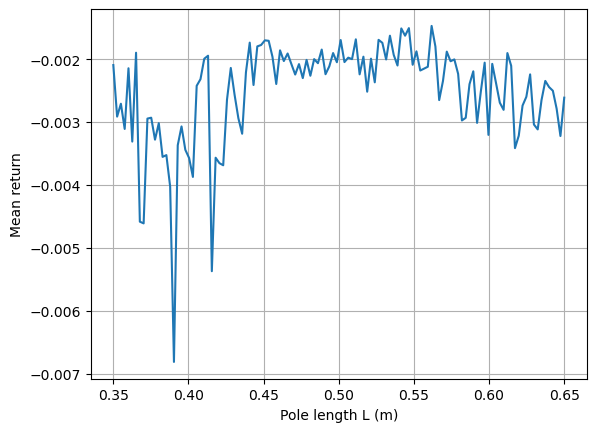

In [80]:
plt.figure()
plt.plot(Ls, mean_returns)
plt.xlabel("Pole length L (m)")
plt.ylabel("Mean return")
plt.grid(True)
plt.savefig("mean_returns_vs_L.pdf", dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()
